# Tutorial 03 - Residual mean reversion: RSI, Bollinger and residual bands

Classical mean reversion asks whether raw price is far from a rolling reference. The DeTime version asks a narrower question: after the current trend and cycle are removed, is the residual unusually cheap or expensive?

The examples keep the classical baselines visible: RSI, Bollinger, raw price z-score and APO. The decomposition-aware versions trade residual pressure and use cycle, trend and volume state as gates.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

from examples.quant_trading.data import load_sample_goog_ohlcv, market_data_manifest, ohlcv_audit_report
from examples.quant_trading.features import build_feature_table, decompose_one_series, walkforward_decompose_ohlcv
from examples.quant_trading.classic_indicators import bollinger_bands, rsi
from examples.quant_trading.strategy_mean_reversion import (
    compare_mean_reversion_suites,
    make_classic_mean_reversion_weight_grid,
    make_detime_mean_reversion_weight_grid,
    run_classical_mean_reversion_baselines,
    run_detime_mean_reversion_baselines,
)
from examples.quant_trading.validation import compare_weight_strategies, turnover_report, write_run_audit, write_run_manifest

pd.set_option("display.max_columns", 30)
report_dir = Path("examples/quant_trading/reports")
report_dir.mkdir(parents=True, exist_ok=True)


## 1. Real OHLCV input

The notebook is executable without network access by using the bundled historical GOOG OHLCV export from the Learn Algorithmic Trading material. The live scripts use Yahoo Finance through `yfinance` when a network is available.


In [2]:
ohlcv_single = load_sample_goog_ohlcv(trim_start="2014-01-01")
ticker = ohlcv_single.attrs.get("symbol", "GOOG")
ohlcv = {field: ohlcv_single[[field]].rename(columns={field: ticker}) for field in ["Open", "High", "Low", "Close", "Volume"]}
prices = ohlcv["Close"]
manifest = market_data_manifest(
    tickers=[ticker],
    start=str(prices.index.min().date()),
    end=str(prices.index.max().date()),
    interval="1d",
    source=ohlcv_single.attrs.get("source", "bundled real sample"),
)
audit = ohlcv_audit_report(ohlcv)
display(audit)


,ticker,first_timestamp,last_timestamp,observations,close_missing_ratio,volume_missing_ratio,zero_volume_ratio,min_close,max_close,median_volume
0,GOOG,2014-01-02,2018-01-02,1008,0.0,0.0,0.0,491.201416,1077.140015,1624450.0


## 2. Classical baselines

These are intentionally simple. They show what the original tutorial style would usually teach before introducing decomposition.


In [3]:
classic_weights = make_classic_mean_reversion_weight_grid(prices, allow_short=False)
classic_table, classic_results = compare_weight_strategies(prices, classic_weights, fee_bps=1.0, slippage_bps=2.0)
display(classic_table[["total_return", "cagr", "sharpe", "max_drawdown", "average_turnover"]].round(4))


,total_return,cagr,sharpe,max_drawdown,average_turnover
strategy,,,,,
classic_rsi_14_reversion,0.2044,0.0476,0.7005,-0.1049,0.0099
classic_price_zscore_63_1p5z,0.3026,0.0683,0.6916,-0.1397,0.0198
classic_apo_10_40_reversion,0.2409,0.0554,0.5102,-0.1571,0.0179
classic_bollinger_20_2z,0.1744,0.0410,0.4239,-0.1769,0.0317


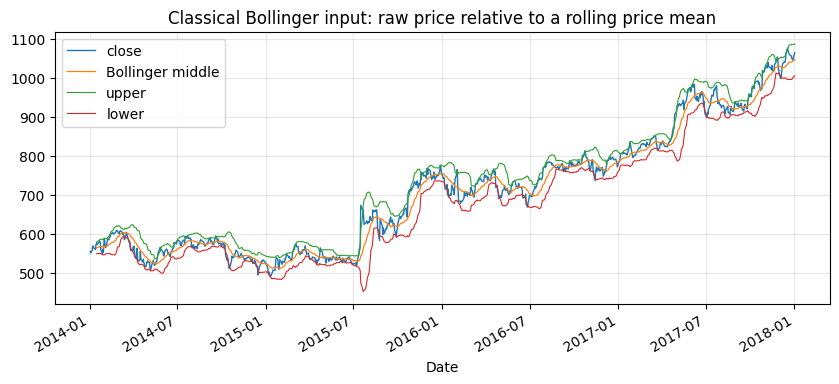

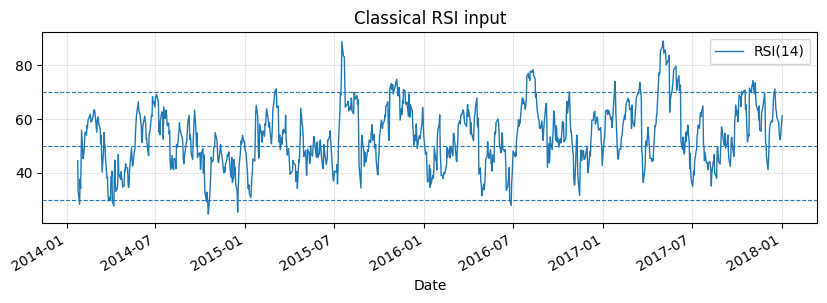

In [4]:
bands = bollinger_bands(prices, window=20, num_std=2.0)
raw_rsi = rsi(prices, window=14)
fig, ax = plt.subplots(figsize=(10, 4))
prices[ticker].plot(ax=ax, linewidth=1.0, label="close")
bands.middle[ticker].plot(ax=ax, linewidth=0.9, label="Bollinger middle")
bands.upper[ticker].plot(ax=ax, linewidth=0.8, label="upper")
bands.lower[ticker].plot(ax=ax, linewidth=0.8, label="lower")
ax.set_title("Classical Bollinger input: raw price relative to a rolling price mean")
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

fig, ax = plt.subplots(figsize=(10, 2.8))
raw_rsi[ticker].plot(ax=ax, linewidth=1.0, label="RSI(14)")
for level in (30, 50, 70):
    ax.axhline(level, linestyle="--", linewidth=0.8)
ax.set_title("Classical RSI input")
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()


## 3. DeTime residual, cycle, trend and volume features

The feature factory uses walk-forward decomposition. The latest feature at each step is carried forward until the next training window closes, avoiding full-sample decomposition leakage.


In [5]:
features = walkforward_decompose_ohlcv(
    ohlcv,
    method="STL",
    period="auto",
    period_candidates=(63, 126, 252),
    train_window=504,
    step=5,
    z_window=63,
)
feature_tail = build_feature_table(prices, features).tail(120)
display(feature_tail.tail(5).round(4))
feature_tail.to_csv(report_dir / "column_03_feature_table_tail.csv")


,component_stability,cycle,cycle_amplitude,cycle_position,cycle_slope,cycle_turn_up,cycle_z,realized_vol_20,reconstruction_error,residual,residual_abs_z,residual_vol,residual_z,return_1d,season,...,volume_cycle_turn_up,volume_cycle_z,volume_participation,volume_reconstruction_error,volume_residual,volume_residual_abs_z,volume_residual_vol,volume_residual_z,volume_selected_period,volume_shock,volume_trend,volume_trend_acceleration,volume_trend_gap,volume_trend_slope,volume_trend_strength
,GOOG,GOOG,GOOG,GOOG,GOOG,GOOG,GOOG,GOOG,GOOG,GOOG,GOOG,GOOG,GOOG,GOOG,GOOG,...,GOOG,GOOG,GOOG,GOOG,GOOG,GOOG,GOOG,GOOG,GOOG,GOOG,GOOG,GOOG,GOOG,GOOG,GOOG
Date,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2017-12-26,0.9853,0.0456,0.0438,1.0414,-0.0051,0.0,0.6138,0.1515,0.0,0.0004,0.1109,0.0149,0.1109,-0.0032,0.0456,...,0.0,-0.5708,2.0,0.0,-0.2911,2.3259,0.1243,-2.3259,126.0,2.3259,14.0559,-0.0,-0.514,-0.0011,-0.0031
2017-12-27,0.9853,0.0456,0.0438,1.0414,-0.0051,0.0,0.6138,0.1518,0.0,0.0004,0.1109,0.0149,0.1109,-0.0070,0.0456,...,0.0,-0.5708,2.0,0.0,-0.2911,2.3259,0.1243,-2.3259,126.0,2.3259,14.0559,-0.0,-0.514,-0.0011,-0.0031
2017-12-28,0.9853,0.0456,0.0438,1.0414,-0.0051,0.0,0.6138,0.1226,0.0,0.0004,0.1109,0.0149,0.1109,-0.0012,0.0456,...,0.0,-0.5708,2.0,0.0,-0.2911,2.3259,0.1243,-2.3259,126.0,2.3259,14.0559,-0.0,-0.514,-0.0011,-0.0031
2017-12-29,0.9853,0.0456,0.0438,1.0414,-0.0051,0.0,0.6138,0.1229,0.0,0.0004,0.1109,0.0149,0.1109,-0.0017,0.0456,...,0.0,-0.5708,2.0,0.0,-0.2911,2.3259,0.1243,-2.3259,126.0,2.3259,14.0559,-0.0,-0.514,-0.0011,-0.0031
2018-01-02,0.9853,0.0456,0.0438,1.0414,-0.0051,0.0,0.6138,0.1270,0.0,0.0004,0.1109,0.0149,0.1109,0.0178,0.0456,...,0.0,-0.5708,2.0,0.0,-0.2911,2.3259,0.1243,-2.3259,126.0,2.3259,14.0559,-0.0,-0.514,-0.0011,-0.0031


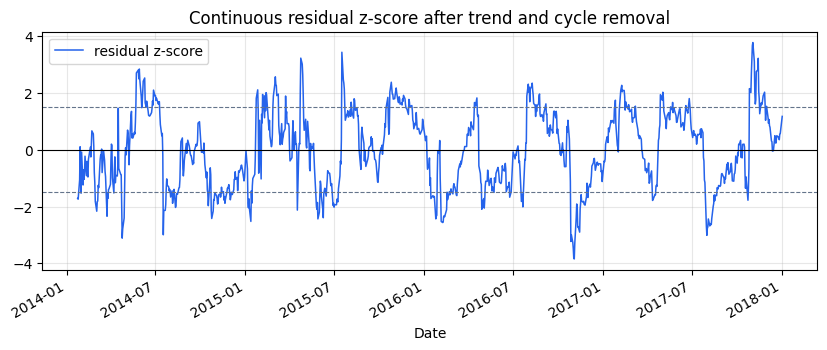

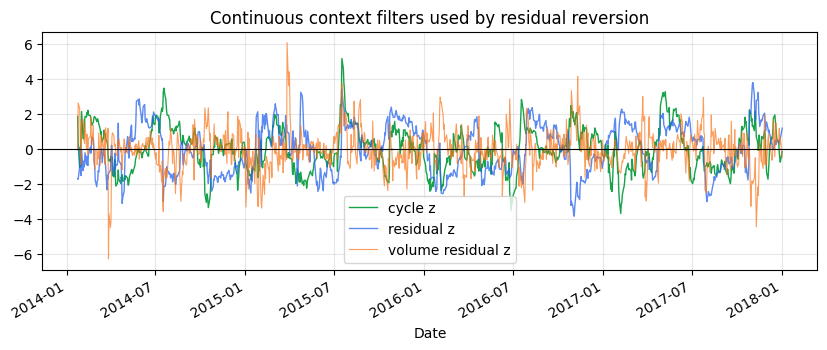

In [6]:
diagnostic = decompose_one_series(
    prices[ticker],
    method="STL",
    period="auto",
    period_candidates=(63, 126, 252),
    z_window=63,
    transform="log",
)
volume_diagnostic = decompose_one_series(
    ohlcv["Volume"][ticker],
    method="STL",
    period=int(diagnostic.attrs.get("period", 126)),
    z_window=63,
    transform="log1p",
)

fig, ax = plt.subplots(figsize=(10, 3.5))
diagnostic["residual_z"].plot(ax=ax, linewidth=1.1, color="#2563eb", label="residual z-score")
for level in (-1.5, 0, 1.5):
    ax.axhline(level, linestyle="--" if level else "-", linewidth=0.8, color="black" if level == 0 else "#64748b")
ax.set_title("Continuous residual z-score after trend and cycle removal")
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

fig, ax = plt.subplots(figsize=(10, 3.5))
diagnostic["cycle_z"].plot(ax=ax, linewidth=1.0, color="#16a34a", label="cycle z")
diagnostic["residual_z"].plot(ax=ax, linewidth=1.0, color="#2563eb", alpha=0.75, label="residual z")
volume_diagnostic["residual_z"].plot(ax=ax, linewidth=0.8, color="#f97316", alpha=0.70, label="volume residual z")
ax.axhline(0, color="black", linewidth=0.8)
ax.set_title("Continuous context filters used by residual reversion")
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()


## 4. Residual reversion strategies

The DeTime variants do not directly buy a lower band break. They require a negative residual, a non-broken trend state, a turning cycle and non-weak volume participation.


In [7]:
detime_weights = make_detime_mean_reversion_weight_grid(prices, features, allow_short=False)
detime_table, detime_results = compare_weight_strategies(prices, detime_weights, fee_bps=1.0, slippage_bps=2.0)
display(detime_table[["total_return", "cagr", "sharpe", "max_drawdown", "average_turnover"]].round(4))


,total_return,cagr,sharpe,max_drawdown,average_turnover
strategy,,,,,
detime_residual_rsi_14,0.3032,0.0685,1.1070,-0.0752,0.0159
detime_residual_band_1p25z,0.2422,0.0557,0.7742,-0.1132,0.0159
detime_residual_z_1p0_cycle_volume,0.2243,0.0519,0.7333,-0.1132,0.0179
detime_trend_pullback_residual,0.2243,0.0519,0.7333,-0.1132,0.0179


In [8]:
classical = run_classical_mean_reversion_baselines(prices, allow_short=False, fee_bps=1.0, slippage_bps=2.0)
detime = run_detime_mean_reversion_baselines(prices, features, allow_short=False, fee_bps=1.0, slippage_bps=2.0)
comparison = compare_mean_reversion_suites(classical, detime)
display(comparison[["strategy_group", "cagr", "sharpe", "max_drawdown", "average_turnover", "hit_rate"]].round(4))
comparison.to_csv(report_dir / "column_03_strategy_comparison.csv")
turnover_report({**classic_weights, **detime_weights}).to_csv(report_dir / "column_03_turnover_report.csv")
write_run_audit(report_dir, data_manifest=manifest, audit=audit, strategy_stats=comparison, prefix="column_03")
manifest_path = write_run_manifest(
    report_dir / "column_03_run_manifest.json",
    command="notebook:03_residual_mean_reversion_rsi_bollinger",
    dataset="bundled_real_GOOG",
    strategies=list(comparison.index),
    result_file=str(report_dir / "column_03_strategy_comparison.csv"),
)
manifest_path.as_posix()


,strategy_group,cagr,sharpe,max_drawdown,average_turnover,hit_rate
strategy,,,,,,
detime_residual_rsi_14,detime_residual_mean_reversion,0.0685,1.1070,-0.0752,0.0159,0.0992
detime_residual_band_1p25z,detime_residual_mean_reversion,0.0557,0.7742,-0.1132,0.0159,0.1002
detime_residual_z_1p0_cycle_volume,detime_residual_mean_reversion,0.0519,0.7333,-0.1132,0.0179,0.0992
detime_trend_pullback_residual,detime_residual_mean_reversion,0.0519,0.7333,-0.1132,0.0179,0.0992
classic_rsi_14_reversion,classical_mean_reversion,0.0476,0.7005,-0.1049,0.0099,0.0427
classic_price_zscore_63_1p5z,classical_mean_reversion,0.0683,0.6916,-0.1397,0.0198,0.1220
classic_apo_10_40_reversion,classical_mean_reversion,0.0554,0.5102,-0.1571,0.0179,0.1647
classic_bollinger_20_2z,classical_mean_reversion,0.0410,0.4239,-0.1769,0.0317,0.0992


'examples/quant_trading/reports/column_03_run_manifest.json'

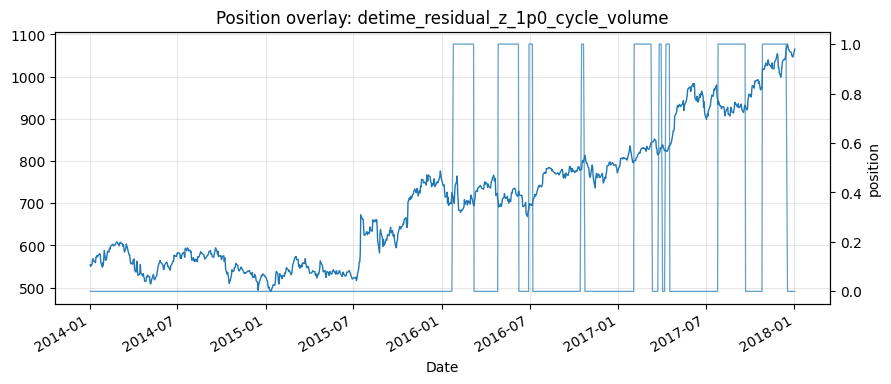

In [9]:
chosen = "detime_residual_z_1p0_cycle_volume"
fig, ax1 = plt.subplots(figsize=(10, 4))
prices[ticker].plot(ax=ax1, linewidth=1.0, label="close")
ax1.set_title(f"Position overlay: {chosen}")
ax2 = ax1.twinx()
detime_weights[chosen][ticker].plot(ax=ax2, linewidth=0.9, alpha=0.7, label="position")
ax2.set_ylabel("position")
ax1.grid(True, alpha=0.3)
plt.show()


## Takeaway

Mean reversion needs a target. Raw price bands mix trend, cycle and residual. Residual reversion narrows the trade to the part left over after the current structure has been extracted, while volume and stability filters reduce trades in weak states.
